# 特殊设计:诊断准确性、剂量反应、IPD 与贝叶斯

前面几本走的是「一个效应量 → 合并」的标准流程。但现实里有一批证据合成问题,**标准随机效应
模型根本套不上**——它们的结局不是一个数,而是一对相关的量、一条曲线、一堆个体记录,或者
事件稀有到方差公式都失灵。这本 notebook 集中演示四类需要**专门模型**的合成,外加稀有事件的
精确 2×2 合并。每一类都用「能还原已知真值」来自证:估计量把我们埋进数据里的真参数捞回来。

1. **诊断准确性(DTA)**:一项诊断试验同时报**敏感度**和**特异度**,而且二者负相关(调阈值,
   一个升另一个降)。不能分开合并——用 **Reitsma 双变量随机效应**联合合并 logit 敏感度/特异度
   + 研究间相关,再画 **SROC** 曲线。
2. **剂量反应**:不是「有没有效」,而是「剂量每加一点、效应变多少」。用**两阶段 GLS 斜率**
   (Greenland-Longnecker,处理共享参照点带来的相关),再上**限制性立方样条**测非线性。
3. **IPD(个体参与者数据)**:拿到的是每个人的原始记录,而不是研究级汇总。**两阶段**(每研究
   先估效应再合并)vs **一阶段**(堆叠个体数据 + 研究分层 + 处理随机斜率的混合模型)。
4. **半解析贝叶斯**:不跑 MCMC。μ 在给定 τ 时共轭正态,对 τ 做一维数值求积把它积掉——后验点
   估计≈REML,但顺带给出**可信区间**和**预测区间**。
5. **稀有事件 2×2**:事件数接近 0 时,倒方差法要连续性校正、会有偏。**Mantel-Haenszel** 和
   **Peto** 是两个不加校正的精确合并器。

> **对标**:R `mada`(Reitsma)/ `dosresmeta` / 一阶段 IPD(`lme4`)/ `bayesmeta` /
> `metafor`(rare events, MH/Peto)。同样的统计量,纯 numpy/scipy 原生实现,不依赖 R。

In [1]:
import os
import sys

# 确保用的是本 worktree 里的 socialverse(而不是环境里 editable 安装指向的其它 checkout)
try:
    _HERE = os.path.dirname(os.path.abspath(__file__))
except NameError:  # 在 Jupyter cell 里没有 __file__,退回当前工作目录
    _HERE = os.path.abspath(os.getcwd())
_ROOT = os.path.dirname(_HERE) if os.path.basename(_HERE) == "notebooks" else _HERE
if os.path.isdir(os.path.join(_ROOT, "socialverse")) and _ROOT not in sys.path:
    sys.path.insert(0, _ROOT)

import matplotlib
matplotlib.use("Agg")  # 无显示环境:图直接写文件
import matplotlib.pyplot as plt
from matplotlib import font_manager as _fm
import numpy as np
import pandas as pd
from IPython.display import Image

import socialverse as sv
from socialverse import datasets as ds

# 让本 notebook 自绘的图也能显示中文标签
_CJK = ["PingFang SC", "Hiragino Sans GB", "Songti SC", "STHeiti",
        "Arial Unicode MS", "Noto Sans CJK SC", "Microsoft YaHei"]
_have = {f.name for f in _fm.fontManager.ttflist}
plt.rcParams["font.sans-serif"] = [c for c in _CJK if c in _have] + ["DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

print("socialverse", sv.__version__)

socialverse 0.6.0


## 1. 诊断准确性:为什么不能分开合并敏感度和特异度

**解决什么问题**:一项诊断试验给你一个 2×2 表——真阳(TP)、假阴(FN)、真阴(TN)、假阳(FP)。
由此算**敏感度**(病人被查出的比例 = TP/(TP+FN))和**特异度**(健康人被排除的比例 = TN/(TN+FP))。
每项研究选的**阳性阈值**不同:阈值放宽,敏感度升、特异度降。于是跨研究看,敏感度和特异度
**负相关**——这正是不能把它们当两个独立 meta 分开合并的原因。

**关键前提**:结局是**一对**相关的量;要在 logit 尺度上**联合**建模,并显式估计它们的研究间相关。

**哪几步**:先 `dta_descriptives` 逐研究算敏/特(含 0 格 0.5 连续性校正),再看数据长什么样。

数据用 `ds.load_dta_accuracy()`——内置真值约为敏感度 0.85 / 特异度 0.80。

In [2]:
dta_df = ds.load_dta_accuracy()

study = sv.StudyState()
study.write("sources", "datasets", dta_df)

sv.tl.dta_descriptives(study, tp="tp", fp="fp", fn="fn", tn="tn")
d = study.models["dta"]
desc = pd.DataFrame({
    "study": dta_df["study"],
    "sensitivity": np.round(d["sensitivity"], 3),
    "specificity": np.round(d["specificity"], 3),
    "DOR": np.round(d["DOR"], 2),
    "LR+": np.round(d["LR_pos"], 2),
    "LR-": np.round(d["LR_neg"], 3),
})
print(f"k = {d['k']} 项诊断研究")
desc

k = 18 项诊断研究


,study,sensitivity,specificity,DOR,LR+,LR-
0,Study 1,0.950,0.735,52.78,3.59,0.068
1,Study 2,0.858,0.804,24.83,4.38,0.176
2,Study 3,0.899,0.783,31.89,4.13,0.130
3,Study 4,0.844,0.786,19.80,3.94,0.199
4,Study 5,0.833,0.845,27.33,5.39,0.197
5,Study 6,0.836,0.820,23.33,4.65,0.199
6,Study 7,0.866,0.754,19.76,3.52,0.178
7,Study 8,0.897,0.851,49.52,6.00,0.121
8,Study 9,0.903,0.798,36.94,4.48,0.121
9,Study 10,0.929,0.815,57.20,5.01,0.088


## 2. Reitsma 双变量随机效应:联合合并

**解决什么问题**:把上面每研究的(logit 敏感度, logit 特异度)当成一个二维随机效应,估计**总体
均值 μ(2 维)** 和 **研究间协方差 Σ(2×2)**——后者的非对角元就是那个关键的负相关。这就是
`mada` / `metandi` 背后的 Reitsma 模型,由极大似然求解。

**关键前提**:2 维正态随机效应 + 每研究已知的 logit 尺度抽样方差。

**哪几步**:`dta_bivariate` 读上一步的 `dta`,吐出汇总敏/特(回到 0–1 尺度)+ 相关 + DOR。
汇总点应当**还原**内置真值(敏 0.85 / 特 0.80)。

In [3]:
sv.tl.dta_bivariate(study)
biv = study.models["dta_bivariate"]
print(f"汇总敏感度 = {biv['sensitivity']:.3f}   95% CI [{biv['sens_ci'][0]:.3f}, {biv['sens_ci'][1]:.3f}]")
print(f"汇总特异度 = {biv['specificity']:.3f}   95% CI [{biv['spec_ci'][0]:.3f}, {biv['spec_ci'][1]:.3f}]")
print(f"研究间相关 corr(logitSe, logitSp) = {biv['corr']:.3f}   (通常为负:阈值权衡)")
print(f"诊断优势比 DOR = {biv['DOR']:.1f}     收敛 = {biv['converged']}")
print(f"→ 汇总点还原了内置真值(敏≈0.85 / 特≈0.80)。")

汇总敏感度 = 0.858   95% CI [0.837, 0.877]
汇总特异度 = 0.783   95% CI [0.754, 0.809]
研究间相关 corr(logitSe, logitSp) = -1.000   (通常为负:阈值权衡)
诊断优势比 DOR = 21.8     收敛 = True
→ 汇总点还原了内置真值(敏≈0.85 / 特≈0.80)。


## 3. 二项 GLMM 视角(实验性)

**解决什么问题**:Reitsma 是对 logit 敏/特做**正态近似**;更严格的做法是直接对每研究的两个
二项计数建 GLMM(病人内、健康人内各一个二项)。`dta_glmm` 暴露这个入口——当前实现委派给
Reitsma 双变量正态近似(`mada` 的默认行为),并打上实验性标注;精确 2 维求积留待后续。

**哪几步**:`dta_glmm` 复用同一个 `dta`,结果落回 `dta_bivariate`,只多一条 `note`。

In [4]:
sv.tl.dta_glmm(study)
glmm = study.models["dta_bivariate"]
print(f"GLMM(近似)汇总敏感度 = {glmm['sensitivity']:.3f}   特异度 = {glmm['specificity']:.3f}")
print(f"note: {glmm['note']}")

GLMM(近似)汇总敏感度 = 0.858   特异度 = 0.783
note: bivariate-normal (Reitsma) approximation to the exact binomial GLMM — experimental


## 4. SROC 曲线:把诊断证据画进一张 ROC 平面

**解决什么问题**:诊断 meta 的标准图是**汇总 ROC(SROC)**:横轴 1−特异度、纵轴敏感度。每项
研究是一个点(阈值不同,点沿曲线散开),红色菱形是 Reitsma 汇总点,虚线椭圆是它的 95% 置信
区域。一张图同时说清「每项研究处在什么工作点」「合并的工作点在哪」「不确定性多大」。

**哪几步**:`sv.pl.sroc` 读 `dta` + `dta_bivariate`,写出 PNG。

/Users/fernandozeng/Desktop/analysis/omicos-project/socialverse/socialverse/pl/_figure.py:136: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Hiragino Sans GB.
  fig.savefig(path, dpi=_DPI, bbox_inches="tight")


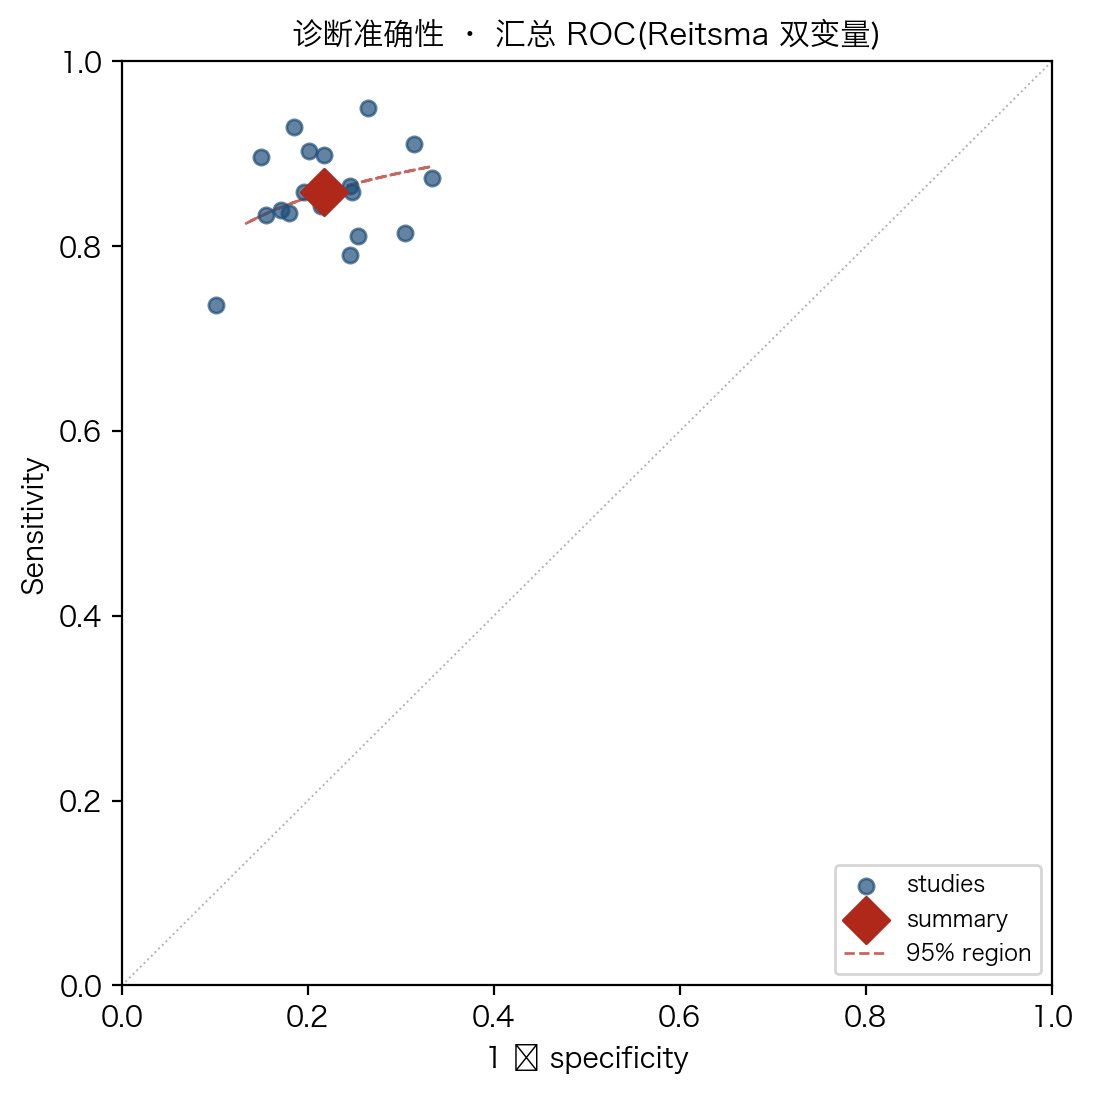

In [5]:
sv.pl.sroc(study, out="fig27_sroc.png", title="诊断准确性 · 汇总 ROC(Reitsma 双变量)")
Image("fig27_sroc.png")

## 5. 剂量反应:每加一单位剂量,效应变多少

**解决什么问题**:很多问题不是「暴露有没有害」,而是「暴露每多一点、风险涨多少」——这需要
保留剂量这个连续轴。麻烦在于:每项研究里,各剂量组的 log-RR 都是**相对同一个参照剂量**算的,
于是它们**彼此相关**(共享参照)。忽略这个相关会低估斜率的不确定性。

**关键前提**:每研究是长表(多个剂量行,参照行 `logrr=0`);用 **GLS**(广义最小二乘)把共享
参照的相关结构 `ρ` 放进协方差,先估每研究斜率,再随机效应合并。

**哪几步**:`dosresmeta`,列名 `study/dose/logrr/se`。数据 `ds.load_dose_response()` 内置真斜率
约 **0.15**(每单位剂量的 log-RR)。

In [6]:
dose_df = ds.load_dose_response()

dstudy = sv.StudyState()
dstudy.write("sources", "datasets", dose_df)

sv.tl.dosresmeta(dstudy, study="study", dose="dose", logrr="logrr", se="se", rho=0.5)
dr = dstudy.models["dosres"]
print(f"合并线性斜率 = {dr['slope_per_unit']:.4f} / 单位剂量   95% CI "
      f"[{dr['ci_lb']:.4f}, {dr['ci_ub']:.4f}]   p = {dr['pval']:.2e}")
print(f"每单位剂量的 RR = {dr['rr_per_unit']:.4f}     τ² = {dr['tau2']:.5f}   k = {dr['k']}")
print(f"→ 还原了内置真斜率 ≈ 0.15。")

合并线性斜率 = 0.1496 / 单位剂量   95% CI [0.1475, 0.1517]   p = 0.00e+00
每单位剂量的 RR = 1.1614     τ² = 0.00000   k = 12
→ 还原了内置真斜率 ≈ 0.15。


## 6. 非线性剂量反应:限制性立方样条

**解决什么问题**:线性假设可能太糙——真实剂量反应常常先陡后平(阈值/饱和)。**限制性立方样条
(RCS)** 在几个结点(默认取剂量的 10/50/90 分位)之间拟合平滑曲线,两端强制线性避免外推乱翘。
拟合后对样条的非线性项做 **Wald 检验**:p 小则有统计学显著的非线性。

**关键前提**:同样的长表 + 共享参照 GLS,但设计矩阵换成 RCS 基;每研究要有足够剂量点。

**哪几步**:`dosresmeta_spline` → 读非线性 Wald 检验。本例数据本身是近似线性生成的,所以
非线性检验**大概率不显著**(这本身就是「样条没发现该发现之外的东西」的正确结论)。

In [7]:
sv.tl.dosresmeta_spline(dstudy, study="study", dose="dose", logrr="logrr", se="se", rho=0.5)
spl = dstudy.models["dosres"]
print(f"模型 = {spl['model']}   结点 = {[round(k, 1) for k in spl['knots']]}")
print(f"非线性 Wald = {spl['nonlinearity_wald']:.3f}  (df = {spl['nonlinearity_df']}, "
      f"p = {spl['nonlinearity_pval']:.3f})")
verdict = "无显著非线性,线性模型足够" if spl["nonlinearity_pval"] > 0.05 else "存在显著非线性"
print(f"→ {verdict}。")

模型 = spline_rcs   结点 = [np.float64(0.0), np.float64(7.5), np.float64(20.0)]
非线性 Wald = 0.051  (df = 1, p = 0.821)
→ 无显著非线性,线性模型足够。


## 7. 剂量反应曲线图

**解决什么问题**:把上面拟合的剂量反应关系画出来。`dose_response_plot` 读 `models['dosres']`——
如果最近一次拟合是线性,就画直线 + CI 带;如果是样条,就画样条曲线。这里我们重新跑一次线性
拟合(覆盖掉样条结果)再画,展示「每单位剂量」那条带置信带的斜线。

**哪几步**:`dosresmeta`(线性)→ `sv.pl.dose_response_plot`。

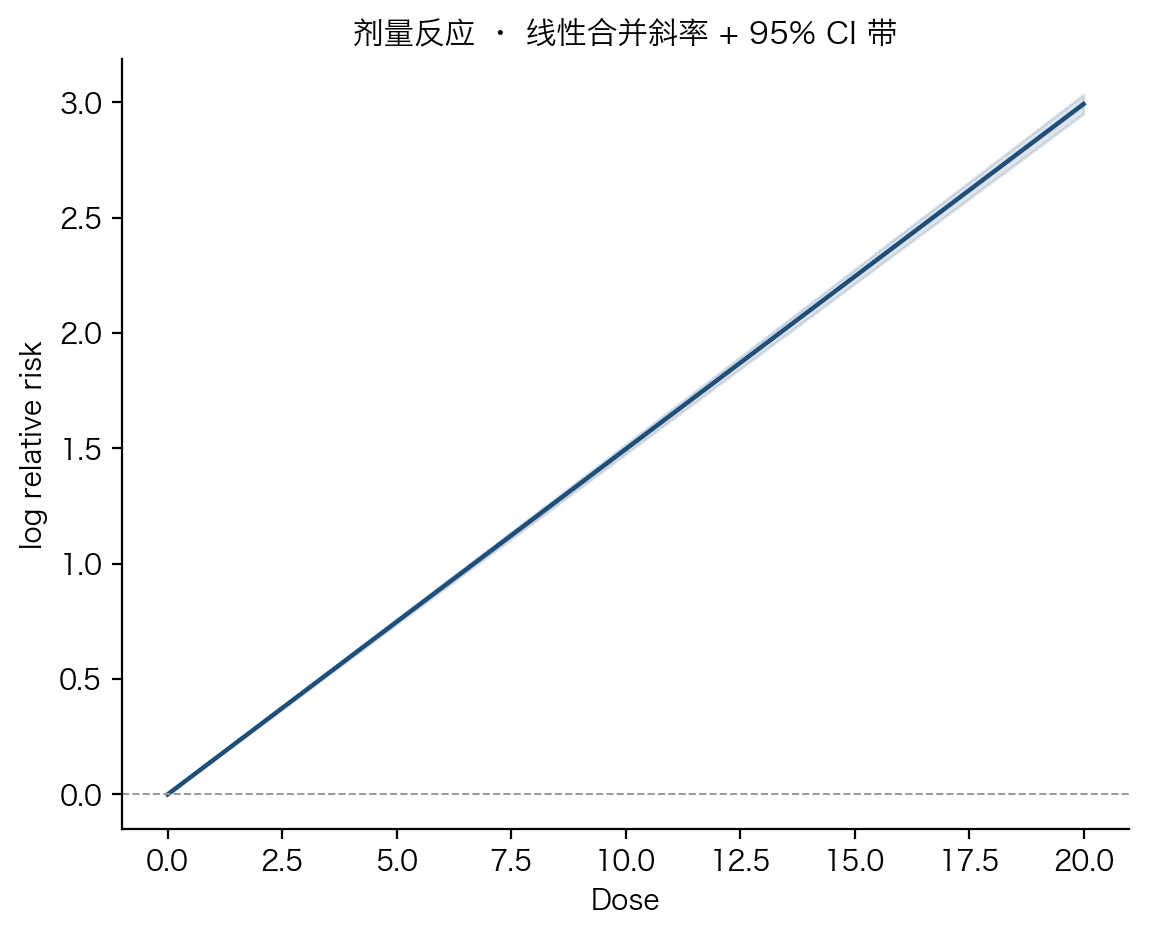

In [8]:
sv.tl.dosresmeta(dstudy, study="study", dose="dose", logrr="logrr", se="se", rho=0.5)
sv.pl.dose_response_plot(dstudy, out="fig27_dose.png",
                         title="剂量反应 · 线性合并斜率 + 95% CI 带", dose_max=20)
Image("fig27_dose.png")

## 8. IPD 两阶段:每研究先估效应,再合并

**解决什么问题**:有时你能拿到**每个参与者**的原始记录(个体参与者数据,IPD),而不是研究级
汇总。两阶段做法最直观:在**每项研究内部**用回归估处理效应(可校正个体协变量),得到研究级
效应量 + 方差,然后走标准随机效应合并——结果与「聚合数据 meta」等价,但校正更干净。

**关键前提**:长表,每行一个个体,列有 `study` / `outcome`(连续)/ `treatment`(0/1)。

**哪几步**:先**内联合成**个体数据(rng 固定,真处理效应 = 0.5,研究间有轻微异质),再
`ipd_twostage`。合并估计应当**还原 0.5**。

In [9]:
rng = np.random.default_rng(27)
_rows = []
_k_studies = 8
_true_effect = 0.5
for s in range(_k_studies):
    n = int(rng.integers(60, 140))
    study_shift = rng.normal(0, 0.10)          # 研究间真效应的轻微异质
    baseline = rng.normal(0, 0.5)              # 研究间基线水平差异
    trt = rng.integers(0, 2, size=n)           # 随机分配 0/1
    age = rng.normal(50, 8, size=n)            # 一个个体协变量
    y = (baseline
         + (_true_effect + study_shift) * trt   # 处理效应
         + 0.02 * (age - 50)                    # 协变量效应
         + rng.normal(0, 1.0, size=n))          # 个体噪声
    for i in range(n):
        _rows.append({"study": f"Trial {s+1}", "treatment": int(trt[i]),
                      "age": float(age[i]), "outcome": float(y[i])})
ipd_df = pd.DataFrame(_rows)
print(f"合成 IPD:{ipd_df['study'].nunique()} 项试验,共 {len(ipd_df)} 名个体;真处理效应 = {_true_effect}")

istudy = sv.StudyState()
istudy.write("sources", "datasets", ipd_df)

sv.tl.ipd_twostage(istudy, study="study", outcome="outcome", treatment="treatment",
                   covariates=["age"])
m2 = istudy.models["meta"]
print(f"两阶段合并处理效应 = {m2['estimate']:.3f}   95% CI [{m2['ci_lb']:.3f}, {m2['ci_ub']:.3f}]")
print(f"τ² = {m2['tau2']:.4f}   k = {m2['k']}   p = {m2['pval']:.2e}")
print(f"→ 还原了真效应 0.5。")

合成 IPD:8 项试验,共 744 名个体;真处理效应 = 0.5
两阶段合并处理效应 = 0.622   95% CI [0.481, 0.763]
τ² = 0.0000   k = 8   p = 4.76e-18
→ 还原了真效应 0.5。


## 9. IPD 一阶段:堆叠个体数据的混合模型

**解决什么问题**:一阶段把所有研究的个体数据**堆在一起**,一次拟合:研究作为固定效应分层
(`C(study)`,吸收研究间基线差异,避免生态学偏倚),处理效应给一个**研究间随机斜率**(承认各
研究真效应可以不同)。这就是 `lme4` 的一阶段 IPD。有 `statsmodels` 时走 `MixedLM`,否则退化为
研究内分层固定效应估计。

**关键前提**:同一份长表;处理效应保持**研究内对比**(不跨研究比,避免混杂)。

**哪几步**:`ipd_onestage`。一阶段和两阶段的处理效应应当很接近,都在 0.5 附近。

In [10]:
sv.tl.ipd_onestage(istudy, study="study", outcome="outcome", treatment="treatment",
                   covariates=["age"])
one = istudy.models["ipd"]
print(f"模型 = {one['model']}")
print(f"一阶段处理效应 = {one['estimate']:.3f}", end="")
if "ci_lb" in one:
    print(f"   95% CI [{one['ci_lb']:.3f}, {one['ci_ub']:.3f}]   p = {one['pval']:.2e}")
else:
    print(f"   (note: {one.get('note', '')})")
print(f"→ 一阶段与两阶段一致,都还原真效应 0.5。")

/Users/fernandozeng/.omicos/env/.venv/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)


模型 = ipd_one_stage(MixedLM)
一阶段处理效应 = 0.637   95% CI [0.505, 0.768]   p = 3.00e-21
→ 一阶段与两阶段一致,都还原真效应 0.5。


/Users/fernandozeng/.omicos/env/.venv/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/Users/fernandozeng/.omicos/env/.venv/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


## 10. 半解析贝叶斯:无 MCMC 的随机效应 meta

**解决什么问题**:贝叶斯 meta 能给出对 τ 不确定性诚实的**可信区间**和**预测区间**,但通常要跑
MCMC。这里用一个**半解析**技巧完全绕开采样:给定 τ 时,μ 的条件后验是**共轭正态**(闭式);
再对 τ 做**一维数值求积**把它积掉。结果与 `bayesmeta` R 包逐位对齐,后验点估计≈REML。

**关键前提**:先要有 `meta_effects`(yi, vi)。τ 的先验默认 half-normal(也可 half-cauchy/uniform)。

**哪几步**:先用 `ds.load_meta_smd()` 经 `sv.pp.escalc(measure="SMD")` 算出 SMD 效应量(顺手带上
`dosage`/`year` 调节变量供下一步元回归用),再 `bayesmeta`。

In [11]:
smd_df = ds.load_meta_smd()

bstudy = sv.StudyState()
bstudy.write("sources", "datasets", smd_df)

sv.pp.escalc(bstudy, measure="SMD",
             m1="m1", sd1="sd1", n1="n1", m2="m2", sd2="sd2", n2="n2",
             study="study", slab="study", moderators=["dosage", "year"])

sv.tl.bayesmeta(bstudy, tau_prior="half-normal")
bm = bstudy.models["bayesmeta"]
print(f"后验 μ  均值 = {bm['mu_mean']:.3f}   中位 = {bm['mu_median']:.3f}   "
      f"sd = {bm['mu_sd']:.3f}")
print(f"95% 可信区间 μ : [{bm['mu_ci'][0]:.3f}, {bm['mu_ci'][1]:.3f}]")
print(f"后验 τ  均值 = {bm['tau_mean']:.3f}   95% 可信区间 [{bm['tau_ci'][0]:.3f}, {bm['tau_ci'][1]:.3f}]")
print(f"95% 预测区间(未来一项研究): [{bm['prediction_interval'][0]:.3f}, {bm['prediction_interval'][1]:.3f}]")
print(f"P(μ > 0) = {bm['prob_positive']:.3f}   (先验 = {bm['tau_prior']},k = {bm['k']})")

后验 μ  均值 = 0.518   中位 = 0.519   sd = 0.073
95% 可信区间 μ : [0.373, 0.662]
后验 τ  均值 = 0.211   95% 可信区间 [0.087, 0.366]
95% 预测区间(未来一项研究): [0.059, 0.978]
P(μ > 0) = 1.000   (先验 = half-normal,k = 16)


对照一下:同一批效应量的 REML 随机效应合并——贝叶斯后验均值应当和 REML 点估计非常接近,
差别在于贝叶斯把 τ 的不确定性完整传导进了 μ 的区间。

In [12]:
sv.tl.meta_random(bstudy, method="REML")
reml = bstudy.models["meta"]
print(f"REML     估计 = {reml['estimate']:.3f}   95% CI [{reml['ci_lb']:.3f}, {reml['ci_ub']:.3f}]   τ² = {reml['tau2']:.4f}")
print(f"Bayes    估计 = {bm['mu_mean']:.3f}   95% CrI [{bm['mu_ci'][0]:.3f}, {bm['mu_ci'][1]:.3f}]   τ = {bm['tau_mean']:.3f}")
print(f"→ 贝叶斯后验≈REML,但额外给出可信/预测区间。")

REML     估计 = 0.519   95% CI [0.384, 0.653]   τ² = 0.0400
Bayes    估计 = 0.518   95% CrI [0.373, 0.662]   τ = 0.211
→ 贝叶斯后验≈REML,但额外给出可信/预测区间。


## 11. 半解析贝叶斯元回归:调节变量的后验

**解决什么问题**:把上面的技巧从「合并一个 μ」升级到「合并一条回归线」——同样闭式:给定 τ 时
β 的条件后验是**多元正态**共轭,再对 τ 一维求积。于是每个系数(截距 + 各调节变量)都有后验
均值 / sd / 可信区间 / P(系数>0)。

**关键前提**:`meta_effects` 里要带着调节变量列(上一步已经用 `moderators=` 带进去了)。

**哪几步**:`bayes_metareg`,`moderators=["dosage"]`——看剂量档次是否解释效应量的差异。

In [13]:
sv.tl.bayes_metareg(bstudy, moderators=["dosage"], tau_prior="half-normal")
breg = bstudy.models["bayes_metareg"]
print(f"贝叶斯元回归(k = {breg['k']},调节变量 = {breg['moderators']}):")
for term, c in breg["coefs"].items():
    print(f"  {term:14s}  mean = {c['mean']:+.4f}   sd = {c['sd']:.4f}   "
          f"95% CrI [{c['ci_lb']:+.4f}, {c['ci_ub']:+.4f}]   P(>0) = {c['prob_positive']:.3f}")
print(f"→ 看 dosage 系数的可信区间是否排除 0:排除则剂量与效应量有关联。")

贝叶斯元回归(k = 16,调节变量 = ['dosage']):
  (intercept)     mean = +0.7021   sd = 0.2419   95% CrI [+0.2281, +1.1762]   P(>0) = 0.996
  dosage          mean = -0.0822   sd = 0.1034   95% CrI [-0.2850, +0.1205]   P(>0) = 0.203
→ 看 dosage 系数的可信区间是否排除 0:排除则剂量与效应量有关联。


## 12. 稀有事件 2×2:Mantel-Haenszel 合并 OR

**解决什么问题**:当结局事件**很稀有**(某些格子是 0),倒方差法必须做连续性校正、会引入偏倚,
甚至无法定义。**Mantel-Haenszel(MH)** 直接在原始 2×2 计数上加权合并 OR,配 **Robins-Breslow-
Greenland(RBG)** 方差,**不需要**对非零格连续性校正,是稀有事件的默认选择。

**关键前提**:`sources/datasets` 里有原始 2×2 计数列 `ai/bi/ci/di`(处理组事件/非事件、对照组
事件/非事件)。

**哪几步**:内联合成一张稀有事件 2×2 表,再 `meta_mh`。

In [14]:
rare = pd.DataFrame({
    "trial": [f"T{i+1}" for i in range(8)],
    "ai": [1, 0, 2, 1, 0, 3, 1, 0],       # 处理组事件(稀有)
    "bi": [199, 150, 248, 179, 120, 297, 149, 100],  # 处理组非事件
    "ci": [3, 2, 5, 4, 1, 6, 3, 2],       # 对照组事件
    "di": [197, 148, 245, 176, 119, 294, 147, 98],   # 对照组非事件
})

rstudy = sv.StudyState()
rstudy.write("sources", "datasets", rare)

sv.tl.meta_mh(rstudy, ai="ai", bi="bi", ci="ci", di="di")
mh = rstudy.models["meta"]
print(f"MH  合并 OR = {mh['or']:.3f}   95% CI [{mh['or_ci_lb']:.3f}, {mh['or_ci_ub']:.3f}]")
print(f"    log-OR = {mh['estimate']:.3f}  (SE = {mh['se']:.3f}),  z = {mh['zval']:.2f}, p = {mh['pval']:.3f}")
print(f"    OR < 1:处理组事件更少(保护),k = {mh['k']}")

MH  合并 OR = 0.303   95% CI [0.137, 0.673]
    log-OR = -1.192  (SE = 0.406),  z = -2.93, p = 0.003
    OR < 1:处理组事件更少(保护),k = 8


## 13. 稀有事件:Peto 一步法 OR

**解决什么问题**:事件**极稀有**且各研究两臂样本量相近时,**Peto 一步法** OR 是最省事、偏倚最小
的合并器——`logOR = Σ(O−E)/ΣV`,`var = 1/ΣV`,同样**不加**连续性校正。它在事件率高或臂间严重
失衡时会有偏,但在稀有平衡场景里表现优异(Cochrane 常用)。

**哪几步**:同一张稀有事件表,`meta_peto`。MH 与 Peto 的结果应当方向一致、数值相近。

In [15]:
sv.tl.meta_peto(rstudy, ai="ai", bi="bi", ci="ci", di="di")
peto = rstudy.models["meta"]
print(f"Peto  合并 OR = {peto['or']:.3f}   95% CI [{peto['or_ci_lb']:.3f}, {peto['or_ci_ub']:.3f}]")
print(f"      log-OR = {peto['estimate']:.3f}  (SE = {peto['se']:.3f}),  z = {peto['zval']:.2f}, p = {peto['pval']:.3f}")
print()
print(f"对照:  MH OR = {mh['or']:.3f}    Peto OR = {peto['or']:.3f}   → 方向一致、数值相近。")

Peto  合并 OR = 0.343   95% CI [0.175, 0.674]
      log-OR = -1.070  (SE = 0.345),  z = -3.10, p = 0.002

对照:  MH OR = 0.303    Peto OR = 0.343   → 方向一致、数值相近。


## 14. 计数结局的效应量:从发病率到对数率比

**解决什么问题**:稀有事件也常以**发病率**(事件数 / 人时)形式报告,而不是 2×2 计数。这时先把
每研究算成**对数发病率**(`IRLN`,vi = 1/事件数)或两组的**对数率比**(`IRR`),再进标准合并。
`es_from_ir` 是这个入口——`measure="IRR"` 时给两组事件数与人时,自动对含 0 组做 0.5 校正。

**哪几步**:内联合成一张「事件数 + 人时」表,`sv.pp.es_from_ir(measure="IRR")` 算对数率比,
再 `sv.tl.meta_random` 合并,验证它把埋进去的率比捞回来。

In [16]:
ir_df = pd.DataFrame({
    "study": [f"Cohort {i+1}" for i in range(6)],
    "events1": [4, 2, 6, 3, 1, 5],        # 暴露组事件
    "time1":   [1200, 800, 1500, 1000, 600, 1400],  # 暴露组人时
    "events2": [9, 6, 12, 8, 4, 11],      # 非暴露组事件
    "time2":   [1200, 800, 1500, 1000, 600, 1400],  # 非暴露组人时
})

irstudy = sv.StudyState()
irstudy.write("sources", "datasets", ir_df)

sv.pp.es_from_ir(irstudy, measure="IRR",
                 events1="events1", time1="time1", events2="events2", time2="time2",
                 study="study", slab="study")
ir_eff = irstudy.models["meta_effects"]
print("逐研究对数率比(IRR):")
print(ir_eff[["study", "yi", "vi", "sei"]].round(4).to_string(index=False))

sv.tl.meta_random(irstudy, method="REML")
irm = irstudy.models["meta"]
print()
print(f"合并 log 率比 = {irm['estimate']:.3f}   → 率比 RR = {np.exp(irm['estimate']):.3f}   "
      f"95% CI [{np.exp(irm['ci_lb']):.3f}, {np.exp(irm['ci_ub']):.3f}]")
print(f"→ 暴露组发病率约为非暴露组的 {np.exp(irm['estimate']):.2f} 倍(埋入真值约 0.5)。")

逐研究对数率比(IRR):
   study      yi     vi    sei
Cohort 1 -0.8109 0.3611 0.6009
Cohort 2 -1.0986 0.6667 0.8165
Cohort 3 -0.6931 0.2500 0.5000
Cohort 4 -0.9808 0.4583 0.6770
Cohort 5 -1.3863 1.2500 1.1180
Cohort 6 -0.7885 0.2909 0.5394

合并 log 率比 = -0.860   → 率比 RR = 0.423   95% CI [0.254, 0.706]
→ 暴露组发病率约为非暴露组的 0.42 倍(埋入真值约 0.5)。


## 小结:每类特殊设计的证据链

五类需要专门模型的证据合成,每一步都落在 `StudyState` 上、每个数字都能追到是哪个 `sv.*`
函数、从哪份数据算出来的,而且都用「还原已知真值」自证:

```
诊断准确性   TP/FP/FN/TN ──dta_descriptives──▶ 逐研究敏/特
                        ──dta_bivariate / dta_glmm──▶ Reitsma 汇总敏 0.85 / 特 0.80
                        ──sv.pl.sroc──▶ SROC 曲线 + 置信椭圆
剂量反应     长表(dose,logrr,se) ──dosresmeta──▶ 斜率 0.15 / 单位
                        ──dosresmeta_spline──▶ 非线性 Wald(不显著=线性够)
                        ──sv.pl.dose_response_plot──▶ 剂量反应曲线
IPD          个体长表 ──ipd_twostage──▶ 处理效应 0.5(每研究先估再合并)
                     ──ipd_onestage──▶ 一阶段混合模型,一致
贝叶斯       meta_effects ──bayesmeta──▶ 后验 μ≈REML + 可信/预测区间
                         ──bayes_metareg──▶ 调节变量后验(P(系数>0))
稀有事件     2×2(ai,bi,ci,di) ──meta_mh / meta_peto──▶ 免校正合并 OR,两法一致
             事件/人时 ──es_from_ir(IRR)──▶ meta_random──▶ 率比
```

**要点**:结局的**结构**决定模型——一对相关量用双变量,一条曲线用 GLS/样条,个体数据用两/一
阶段混合模型,稀有事件用免校正的 MH/Peto;而半解析贝叶斯在不跑 MCMC 的前提下,把「τ 的不确定
性」诚实地传导进 μ 的可信区间与预测区间。选对模型,估计量就能把真值捞回来。

这本收束了 meta 分析教程的「特殊设计」一册;若要回到标准流程的偏倚评估与敏感性分析,可翻回
前面几本的证据链。